MOBILE PRICE DATASET

Dataset:
    RAM  Storage  Battery  Camera  ScreenSize  Price
0     2       32     3000       8         5.0   7000
1     3       32     3500      12         5.5   9000
2     4       64     4000      16         6.0  12000
3     4      128     4500      16         6.1  15000
4     6      128     4500      32         6.2  18000
5     6      256     5000      48         6.4  22000
6     8      128     4500      48         6.5  25000
7     8      256     5000      64         6.6  30000
8    12      256     5000      64         6.7  40000
9    12      512     5500     108         6.7  50000
10   16      512     5500     108         6.8  65000
11   16     1024     6000     200         6.9  85000

Number of samples: 12

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   RAM         12 non-null     int64  
 1   Stora

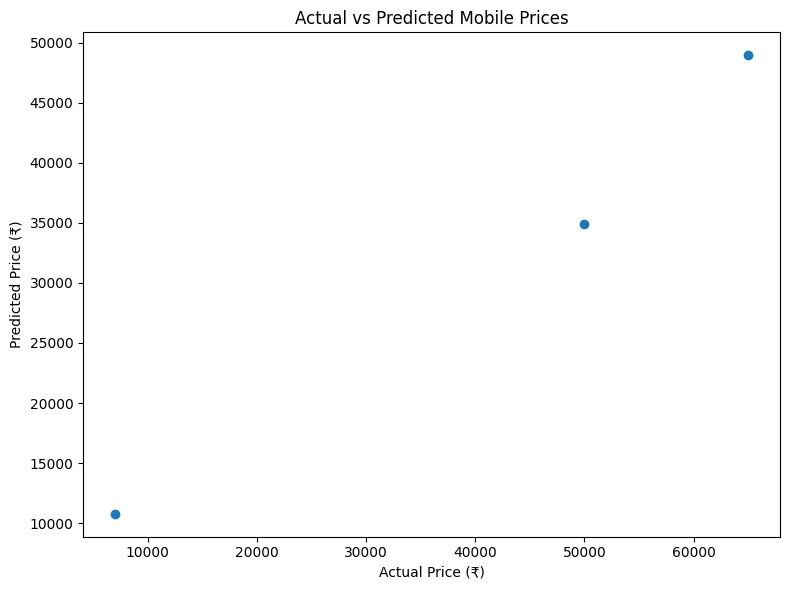

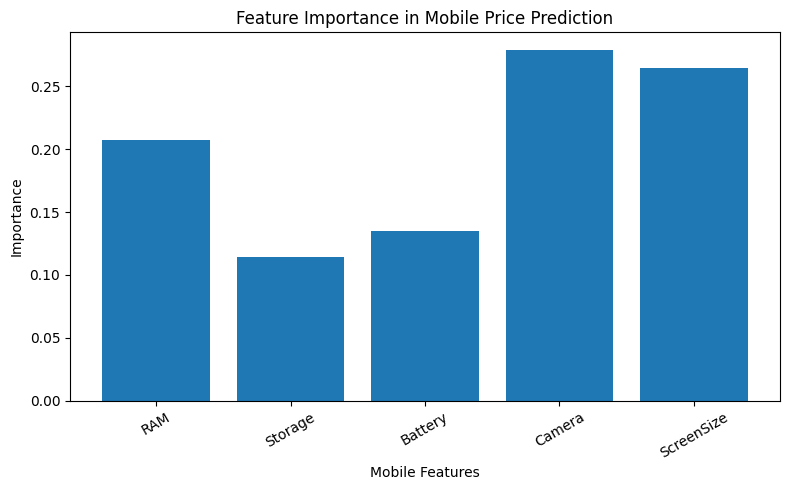


NEW MOBILE PRICE PREDICTION

Mobile Specifications:
RAM        : 8 GB
Storage    : 256 GB
Battery    : 5000 mAh
Camera     : 64 MP
Screen Size: 6.6 inches

Predicted Mobile Price: ₹ 29770.0


In [ ]:
# Experiment: Mobile Price Prediction using Random Forest Regression
# Aim: Implement a Mobile Price Prediction model using
#      an appropriate machine learning algorithm.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ---------------------------------------------------------
# STEP 1: Create Mobile Price Dataset
# ---------------------------------------------------------

data = {
    "RAM": [2, 3, 4, 4, 6, 6, 8, 8, 12, 12, 16, 16],
    "Storage": [32, 32, 64, 128, 128, 256, 128, 256, 256, 512, 512, 1024],
    "Battery": [3000, 3500, 4000, 4500, 4500, 5000,
                4500, 5000, 5000, 5500, 5500, 6000],
    "Camera": [8, 12, 16, 16, 32, 48, 48, 64, 64, 108, 108, 200],
    "ScreenSize": [5.0, 5.5, 6.0, 6.1, 6.2, 6.4,
                   6.5, 6.6, 6.7, 6.7, 6.8, 6.9],
    "Price": [7000, 9000, 12000, 15000, 18000, 22000,
              25000, 30000, 40000, 50000, 65000, 85000]
}

df = pd.DataFrame(data)

print("MOBILE PRICE DATASET")
print("=" * 60)

print("\nDataset:")
print(df)

print("\nNumber of samples:", len(df))

print("\nDataset Information:")
print(df.info())


# ---------------------------------------------------------
# STEP 2: Separate Features and Target
# ---------------------------------------------------------

X = df.drop("Price", axis=1)

y = df["Price"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Variable: Price")


# ---------------------------------------------------------
# STEP 3: Split Dataset into Training and Testing Data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 4: Create Random Forest Regression Model
# ---------------------------------------------------------

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


# ---------------------------------------------------------
# STEP 5: Train the Model
# ---------------------------------------------------------

model.fit(X_train, y_train)

print("\nRandom Forest Regression Model Trained Successfully!")


# ---------------------------------------------------------
# STEP 6: Predict Mobile Prices
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 7: Evaluate Model Performance
# ---------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("\n" + "=" * 60)
print("MOBILE PRICE PREDICTION RESULTS")
print("=" * 60)

print("\nMean Absolute Error (MAE):",
      round(mae, 2))

print("Mean Squared Error (MSE):",
      round(mse, 2))

print("Root Mean Squared Error (RMSE):",
      round(rmse, 2))

print("R² Score:",
      round(r2, 4))


# ---------------------------------------------------------
# STEP 8: Display Actual vs Predicted Prices
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED PRICES")
print("=" * 60)

for actual, predicted in zip(y_test, y_pred):

    print(
        "Actual Price: ₹",
        round(actual, 2),
        "\tPredicted Price: ₹",
        round(predicted, 2)
    )


# ---------------------------------------------------------
# STEP 9: Plot Actual vs Predicted Prices
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")

plt.title(
    "Actual vs Predicted Mobile Prices"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 10: Feature Importance
# ---------------------------------------------------------

feature_importance = model.feature_importances_

plt.figure(figsize=(8, 5))

plt.bar(
    X.columns,
    feature_importance
)

plt.xlabel("Mobile Features")
plt.ylabel("Importance")

plt.title(
    "Feature Importance in Mobile Price Prediction"
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 11: Predict Price of a New Mobile
# ---------------------------------------------------------

new_mobile = pd.DataFrame({
    "RAM": [8],
    "Storage": [256],
    "Battery": [5000],
    "Camera": [64],
    "ScreenSize": [6.6]
})


predicted_price = model.predict(new_mobile)


print("\n" + "=" * 60)
print("NEW MOBILE PRICE PREDICTION")
print("=" * 60)

print("\nMobile Specifications:")

print("RAM        :", new_mobile["RAM"].iloc[0], "GB")
print("Storage    :", new_mobile["Storage"].iloc[0], "GB")
print("Battery    :", new_mobile["Battery"].iloc[0], "mAh")
print("Camera     :", new_mobile["Camera"].iloc[0], "MP")
print("Screen Size:", new_mobile["ScreenSize"].iloc[0], "inches")

print(
    "\nPredicted Mobile Price: ₹",
    round(predicted_price[0], 2)
)